# HW6: токенизаторы, размеры attention и анализ голов

Ноутбук сделан на основе `hw6/tokenizers_tensors_attention_seminar.ipynb` и закрывает все пять пунктов задания.

Что внутри:
1. добавлен еще один токенайзер и проведено сравнение на русском и на коде;
2. вручную выписаны размеры `Q`, `K`, `V` и `QK^T`;
3. для еще одной модели из `transformers` найдены число слоев, голов и размерность;
4. найден конкретный параметр, соответствующий `W_K`;
5. выбрана attention-head с интересным паттерном и описана словами.


In [1]:
import os
os.environ.setdefault('TOKENIZERS_PARALLELISM', 'false')

import math
import random
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from IPython.display import display
from transformers import (
    AutoConfig,
    AutoModel,
    AutoModelForCausalLM,
    AutoTokenizer,
    BertModel,
    logging,
)

logging.set_verbosity_error()

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.grid'] = False


def token_table(tok, text):
    enc = tok(text, return_offsets_mapping=True)
    token_ids = enc['input_ids']
    internal_tokens = tok.convert_ids_to_tokens(token_ids)

    rows = []
    for pos, (token_id, internal_token, (start, end)) in enumerate(zip(token_ids, internal_tokens, enc['offset_mapping'])):
        if start == end == 0 and internal_token in tok.all_special_tokens:
            text_piece = '[SPECIAL]'
        else:
            text_piece = text[start:end].replace('\n', '\\n')
            if text_piece == '':
                if 'Ċ' in internal_token:
                    text_piece = '\\n'
                elif 'Ġ' in internal_token or '▁' in internal_token:
                    text_piece = '[space]'

        rows.append({
            'pos': pos,
            'token_id': token_id,
            'internal_token': internal_token,
            'text_piece': text_piece,
        })

    return pd.DataFrame(rows)


def show_tokenization(tok_name, text, title=None):
    tok = AutoTokenizer.from_pretrained(tok_name)
    df = token_table(tok, text)
    if title is None:
        title = tok_name
    print(f'=== {title} ===')
    print('readable pieces:', df['text_piece'].tolist())
    display(df)
    print('n_tokens =', len(df))
    print()

/home/artem216/hw_spring_semestr_2026/nlp/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Еще токенайзеры: `microsoft/codebert-base` `ai-forever/FRIDA`

In [ ]:
texts = {
    'russian': 'Маленькая собака спит на коврике и смотрит на трансформер.',
    'code': 'def attention(q, k, v):\n    scores = q @ k.T\n    return softmax(scores) @ v',
}

tokenizer_names = {
    'bert-base-uncased': 'BERT WordPiece',
    'gpt2': 'GPT-2 byte-level BPE',
    'google/mt5-small': 'mT5 SentencePiece',
    'xlm-roberta-base': 'XLM-R SentencePiece',
    'microsoft/codebert-base': 'CodeBERT byte-level BPE',
    'ai-forever/FRIDA': 'FRIDA',
}

rows = []
for tok_name, tok_descr in tokenizer_names.items():
    tok = AutoTokenizer.from_pretrained(tok_name)
    row = {'tokenizer': tok_descr, 'hf_name': tok_name}
    for label, text in texts.items():
        row[label] = len(tok(text)['input_ids'])
    rows.append(row)

comparison_df = pd.DataFrame(rows).sort_values('russian').reset_index(drop=True)
comparison_df

,tokenizer,hf_name,russian,code
0,FRIDA byte-level BPE,ai-forever/FRIDA,16,31
1,XLM-R SentencePiece,xlm-roberta-base,19,29
2,mT5 SentencePiece,google/mt5-small,20,29
3,BERT WordPiece,bert-base-uncased,48,27
4,GPT-2 byte-level BPE,gpt2,61,33
5,CodeBERT byte-level BPE,microsoft/codebert-base,63,35


In [3]:
microsoft_tok_name = 'microsoft/codebert-base'

for label, text in texts.items():
    show_tokenization(microsoft_tok_name, text, title=f'CodeBERT | {label}')

=== CodeBERT | russian ===
readable pieces: ['[SPECIAL]', 'М', 'М', 'а', 'л', 'е', 'н', 'ь', 'к', 'а', 'я', '[space]', 'с', 'об', 'б', 'а', 'к', 'а', '[space]', 'с', 'п', 'п', 'и', 'т', 'н', 'н', 'а', 'к', 'к', 'ов', 'в', 'р', 'и', 'к', 'е', 'и', 'и', '[space]', 'с', 'м', 'о', 'т', 'р', 'и', 'т', 'н', 'н', 'а', '[space]', 'т', 'р', 'а', 'н', 'с', 'ф', 'ф', 'о', 'р', 'м', 'е', 'р', '.', '[SPECIAL]']


,pos,token_id,internal_token,text_piece
0,0,0,<s>,[SPECIAL]
1,1,25417,Ð,М
2,2,48,ľ,М
3,3,26161,Ð°,а
4,4,40966,Ð»,л
...,...,...,...,...
58,58,46056,Ð¼,м
59,59,25482,Ðµ,е
60,60,24269,ÑĢ,р
61,61,4,.,.


n_tokens = 63



=== CodeBERT | code ===
readable pieces: ['[SPECIAL]', 'def', 'attention', '(', 'q', ',', 'k', ',', 'v', '):', '\\n', '[space]', '[space]', '[space]', 'scores', '=', 'q', '@', 'k', '.', 'T', '\\n', '[space]', '[space]', '[space]', 'return', 'soft', 'max', '(', 'sc', 'ores', ')', '@', 'v', '[SPECIAL]']


,pos,token_id,internal_token,text_piece
0,0,0,<s>,[SPECIAL]
1,1,9232,def,def
2,2,1503,Ġattention,attention
3,3,1640,(,(
4,4,1343,q,q
5,5,6,",",","
6,6,449,Ġk,k
7,7,6,",",","
8,8,748,Ġv,v
9,9,3256,):,):


n_tokens = 35



In [4]:
frida_tok_name = 'ai-forever/FRIDA'

for label, text in texts.items():
    show_tokenization(frida_tok_name, text, title=f'FRIDA | {label}')

=== FRIDA | russian ===
readable pieces: ['[SPECIAL]', 'Мал', 'енькая', 'собака', 'спит', 'на', 'ков', 'рике', 'и', 'смотрит', 'на', 'транс', 'фор', 'мер', '.', '[SPECIAL]']


,pos,token_id,internal_token,text_piece
0,0,1,<s>,[SPECIAL]
1,1,22052,ÐľÐ°Ð»,Мал
2,2,11188,ÐµÐ½ÑĮÐºÐ°Ñı,енькая
3,3,12292,ĠÑģÐ¾Ð±Ð°ÐºÐ°,собака
4,4,15317,ĠÑģÐ¿Ð¸ÑĤ,спит
5,5,309,ĠÐ½Ð°,на
6,6,7359,ĠÐºÐ¾Ð²,ков
7,7,9158,ÑĢÐ¸ÐºÐµ,рике
8,8,289,ĠÐ¸,и
9,9,8218,ĠÑģÐ¼Ð¾ÑĤÑĢÐ¸ÑĤ,смотрит


n_tokens = 16



=== FRIDA | code ===
readable pieces: ['[SPECIAL]', 'def', 'attention', '(', 'q', ',', 'k', ',', 'v', '):', '\\n', '[space]', 'scores', '=', 'q', '@', 'k', '.', 'T', '\\n', '[space]', 'return', 'soft', 'max', '(', 'sc', 'ores', ')', '@', 'v', '[SPECIAL]']


,pos,token_id,internal_token,text_piece
0,0,1,<s>,[SPECIAL]
1,1,53196,def,def
2,2,45746,Ġattention,attention
3,3,12,(,(
4,4,85,q,q
5,5,16,",",","
6,6,44788,Ġk,k
7,7,16,",",","
8,8,45044,Ġv,v
9,9,7110,):,):


n_tokens = 31



**Вывод по токенизаторам.**

- У byte-level BPE токенизаторов вроде `gpt2`, `CodeBERT` и `FRIDA` странные символы вида `Ð`, `Ñ`, `Ġ` не означают сломанную кодировку. Это их внутреннее представление байтов и пробелов.
- На русском `CodeBERT` все равно работает хуже multilingual-моделей: токенов много, и разбиение получается мелким.
- На коде `CodeBERT` и `FRIDA` выглядят заметно естественнее, потому что их словарь лучше согласован с программным текстом.

## 2. Размеры `Q`, `K`, `V` и `QK^T`

Возьмем конкретные значения:
- `B = 2`
- `T = 7`
- `d_model = 768`
- `h = 12`

Тогда размерность одной головы:

$$
 d_k = d_{model} / h = 768 / 12 = 64
$$


In [5]:
B, T, d_model, h = 2, 7, 768, 12
d_k = d_model // h

shapes_df = pd.DataFrame([
    {'tensor': 'X', 'shape': (B, T, d_model)},
    {'tensor': 'Q', 'shape': (B, h, T, d_k)},
    {'tensor': 'K', 'shape': (B, h, T, d_k)},
    {'tensor': 'V', 'shape': (B, h, T, d_k)},
    {'tensor': 'QK^T', 'shape': (B, h, T, T)},
])
shapes_df

,tensor,shape
0,X,"(2, 7, 768)"
1,Q,"(2, 12, 7, 64)"
2,K,"(2, 12, 7, 64)"
3,V,"(2, 12, 7, 64)"
4,QK^T,"(2, 12, 7, 7)"


- $Q ∈ R^{2 x 12 x 7 x 64}$
- $K ∈ R^{2 x 12 x 7 x 64}$
- $V ∈ R^{2 x 12 x 7 x 64}$
- $QK^T ∈ R^{2 x 12 x 7 x 7}$

## Qwen/Qwen2.5-0.5B

In [6]:
qwen_name = 'Qwen/Qwen2.5-0.5B'
qwen_cfg = AutoConfig.from_pretrained(qwen_name)

qwen_summary = pd.DataFrame([
    {
        'model': qwen_name,
        'hidden_size': qwen_cfg.hidden_size,
        'num_layers': qwen_cfg.num_hidden_layers,
        'num_attention_heads': qwen_cfg.num_attention_heads,
        'num_key_value_heads': qwen_cfg.num_key_value_heads,
        'head_dim': qwen_cfg.hidden_size // qwen_cfg.num_attention_heads,
    }
])
qwen_summary

,model,hidden_size,num_layers,num_attention_heads,num_key_value_heads,head_dim
0,Qwen/Qwen2.5-0.5B,896,24,14,2,64


In [7]:
model = AutoModelForCausalLM.from_config(qwen_cfg)

In [8]:
model

Qwen2ForCausalLM(
  (model): Qwen2Model(
    (embed_tokens): Embedding(151936, 896)
    (layers): ModuleList(
      (0-23): 24 x Qwen2DecoderLayer(
        (self_attn): Qwen2Attention(
          (q_proj): Linear(in_features=896, out_features=896, bias=True)
          (k_proj): Linear(in_features=896, out_features=128, bias=True)
          (v_proj): Linear(in_features=896, out_features=128, bias=True)
          (o_proj): Linear(in_features=896, out_features=896, bias=False)
        )
        (mlp): Qwen2MLP(
          (gate_proj): Linear(in_features=896, out_features=4864, bias=False)
          (up_proj): Linear(in_features=896, out_features=4864, bias=False)
          (down_proj): Linear(in_features=4864, out_features=896, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): Qwen2RMSNorm((896,), eps=1e-06)
        (post_attention_layernorm): Qwen2RMSNorm((896,), eps=1e-06)
      )
    )
    (norm): Qwen2RMSNorm((896,), eps=1e-06)
    (rotary_emb): Qwen2

**Что получилось для Qwen/Qwen2.5-0.5B:**

- скрытая размерность: **896**
- число слоев: **24**
- число attention-heads: **14**
- размерность одной головы: **64**
- число `key/value` голов: **2**

**Интересные особенности attention-механизма:**

- Используется **RoPE**: информация о позиции вносится вращением векторов, а не добавлением обычных positional embeddings.
- Используется **GQA**: `Q` 14 голов, а вот `K` и `V` имеют только 2 головы. Это уменьшает память и ускоряет инференс. Именно поэтому в такой модели размеры проекций `K` и `V` уже не обязаны совпадать с `Q`.

## 4. Конкретный параметр, соответствующий `W_K`


In [9]:
named_params = dict(model.named_parameters())
param_names = [
    'model.layers.0.self_attn.q_proj.weight',
    'model.layers.0.self_attn.k_proj.weight',
    'model.layers.0.self_attn.v_proj.weight',
    'model.layers.0.self_attn.o_proj.weight',
]

proj_df = pd.DataFrame([
    {'parameter': name, 'shape': tuple(named_params[name].shape)}
    for name in param_names
])
proj_df

,parameter,shape
0,model.layers.0.self_attn.q_proj.weight,"(896, 896)"
1,model.layers.0.self_attn.k_proj.weight,"(128, 896)"
2,model.layers.0.self_attn.v_proj.weight,"(128, 896)"
3,model.layers.0.self_attn.o_proj.weight,"(896, 896)"


**Ответ:** параметр, соответствующий `W_K`, это

`model.layers.0.self_attn.k_proj.weight`

Его размерность **`(128, 896)`**.
- `896 = hidden_size`
- `128 = num_key_value_heads * head_dim = 2 * 64`

То есть в этой модели ключи проецируются не в `14 * 64`, а только в `2 * 64`, после чего эти `K/V`-головы используются несколькими `Q`-головами.

## 5. Интересная attention-head

In [10]:
mb_name = 'ai-forever/FRIDA'
mb_text = 'Маленькая собака, увидев кошку у окна, внезапно перестала лаять и просто смотрела на дождь.'

mb_tok = AutoTokenizer.from_pretrained(mb_name)
mb_model = BertModel.from_pretrained(mb_name, attn_implementation='eager')
mb_model.eval()

mb_batch = mb_tok(mb_text, return_tensors='pt')
mb_tokens = mb_tok.convert_ids_to_tokens(mb_batch['input_ids'][0])

with torch.no_grad():
    mb_out = mb_model(**mb_batch, output_attentions=True, return_dict=True)

head_stats = []
for layer_idx, layer_attn in enumerate(mb_out.attentions):
    layer_attn = layer_attn[0]  # (heads, seq, seq)
    for head_idx in range(layer_attn.shape[0]):
        attn = layer_attn[head_idx]
        head_stats.append({
            'layer': layer_idx,
            'head': head_idx,
            'diag_mean': attn.diag().mean().item(),
            'cls_mean': attn[:, 0].mean().item(),
            'sep_mean': attn[:, -1].mean().item(),
            'rowmax_mean': attn.max(dim=-1).values.mean().item(),
        })

head_stats_df = pd.DataFrame(head_stats).sort_values('cls_mean', ascending=False).reset_index(drop=True)
head_stats_df.head(10)


Loading weights: 0it [00:00, ?it/s]


Loading weights: 0it [00:00, ?it/s]

,layer,head,diag_mean,cls_mean,sep_mean,rowmax_mean
0,5,2,0.045507,0.062032,0.049695,0.078009
1,2,5,0.048539,0.057602,0.049177,0.066753
2,11,7,0.046828,0.057588,0.042842,0.064957
3,10,10,0.045742,0.057150,0.045903,0.067344
4,7,11,0.046394,0.057068,0.052227,0.072333
5,8,1,0.045653,0.056676,0.034901,0.065375
6,1,7,0.046172,0.056506,0.049958,0.070359
7,7,4,0.046636,0.056407,0.041092,0.063601
8,4,9,0.045888,0.056082,0.051110,0.069938
9,1,6,0.044996,0.055093,0.059836,0.076205


Топ голов по среднему вниманию в [CLS]:


,layer,head,diag_mean,cls_mean,sep_mean,rowmax_mean
0,5,2,0.045507,0.062032,0.049695,0.078009
1,2,5,0.048539,0.057602,0.049177,0.066753
2,11,7,0.046828,0.057588,0.042842,0.064957
3,10,10,0.045742,0.057150,0.045903,0.067344
4,7,11,0.046394,0.057068,0.052227,0.072333
5,8,1,0.045653,0.056676,0.034901,0.065375
6,1,7,0.046172,0.056506,0.049958,0.070359
7,7,4,0.046636,0.056407,0.041092,0.063601
8,4,9,0.045888,0.056082,0.051110,0.069938
9,1,6,0.044996,0.055093,0.059836,0.076205



Токены:
['<s>', 'ÐľÐ°Ð»', 'ÐµÐ½ÑĮÐºÐ°Ñı', 'ĠÑģÐ¾Ð±Ð°ÐºÐ°', ',', 'ĠÑĥÐ²Ð¸Ð´ÐµÐ²', 'ĠÐºÐ¾ÑĪÐºÑĥ', 'ĠÑĥ', 'ĠÐ¾ÐºÐ½Ð°', ',', 'ĠÐ²Ð½ÐµÐ·Ð°Ð¿Ð½Ð¾', 'ĠÐ¿ÐµÑĢÐµÑģÑĤÐ°Ð»Ð°', 'ĠÐ»', 'Ð°Ñı', 'ÑĤÑĮ', 'ĠÐ¸', 'ĠÐ¿ÑĢÐ¾ÑģÑĤÐ¾', 'ĠÑģÐ¼Ð¾ÑĤÑĢÐµÐ»Ð°', 'ĠÐ½Ð°', 'ĠÐ´Ð¾Ð¶Ð´ÑĮ', '.', '</s>']


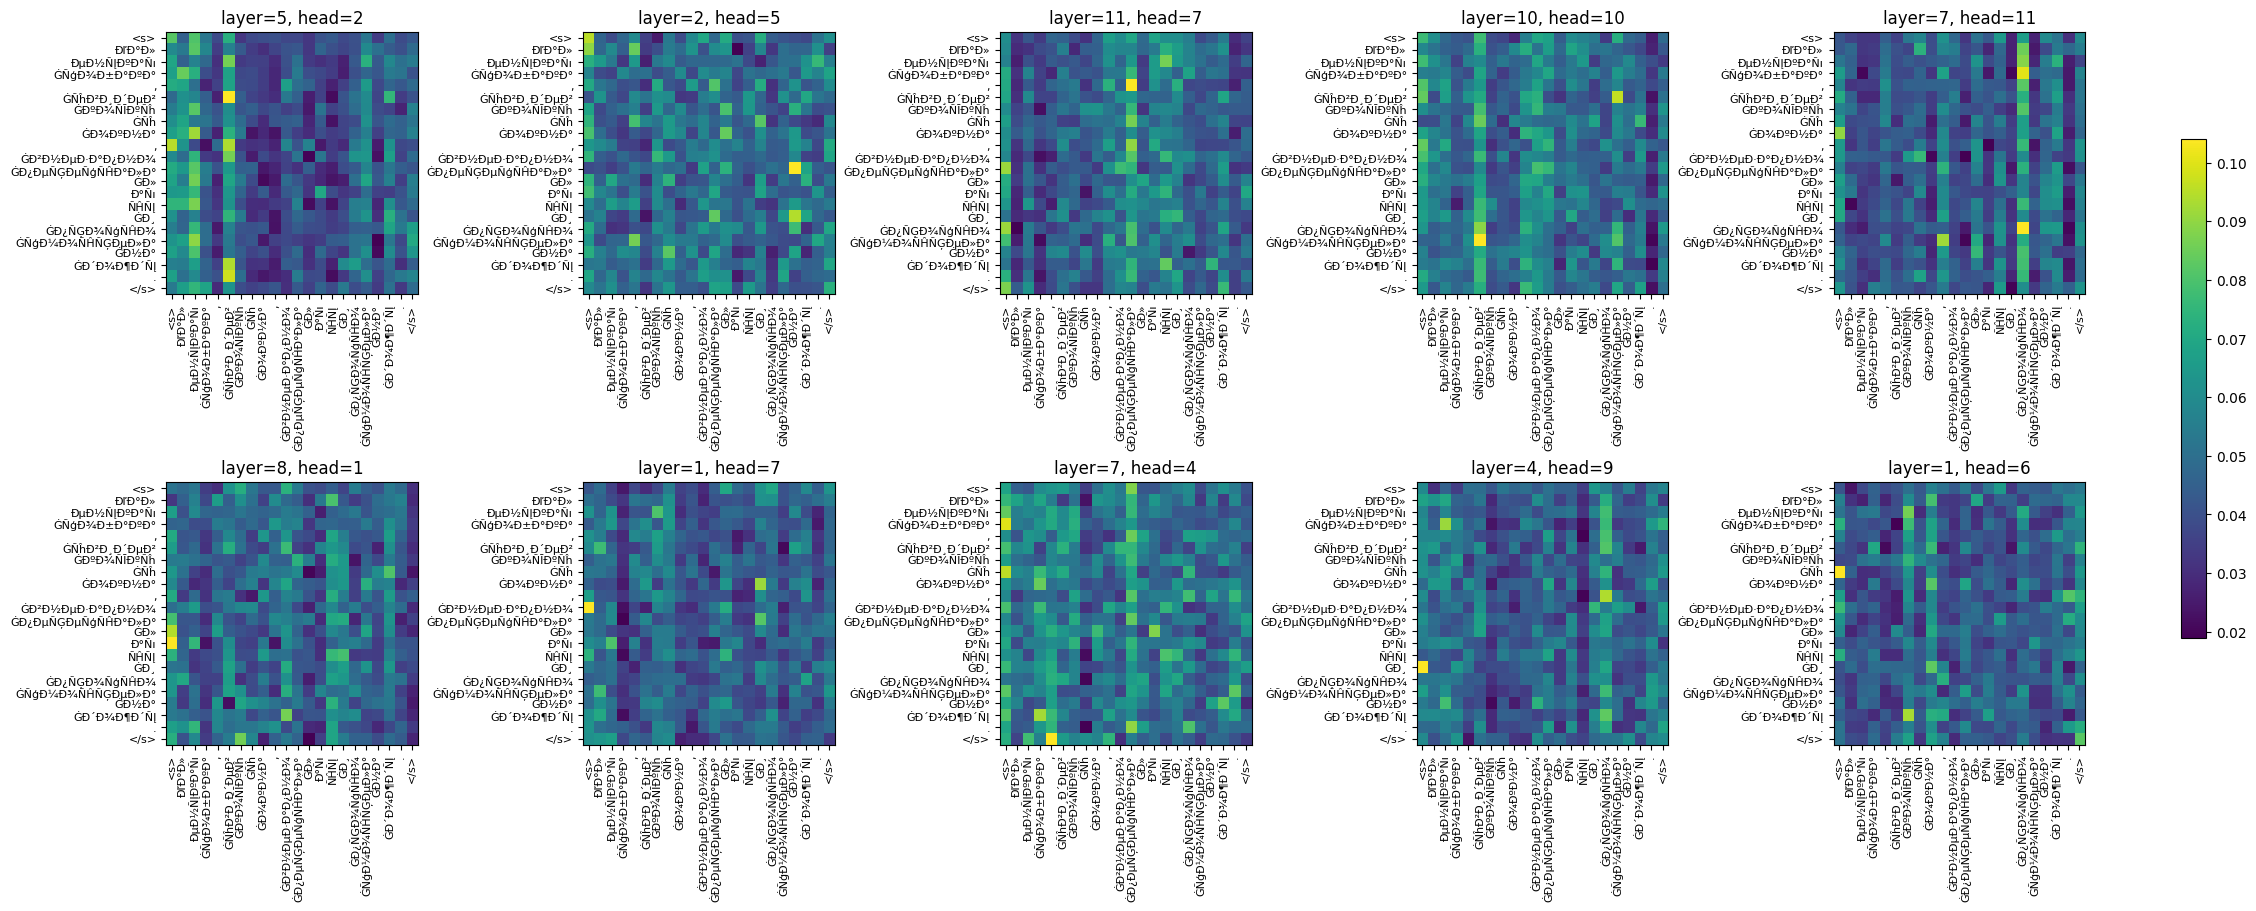

In [11]:
top_n = 10
top_heads = head_stats_df.head(top_n).copy()

print('Топ голов по среднему вниманию в [CLS]:')
display(top_heads)
print('\nТокены:')
print(mb_tokens)

ncols = 5
nrows = math.ceil(top_n / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(4.5 * ncols, 4.5 * nrows), constrained_layout=True)
axes = np.array(axes).reshape(-1)

for ax, (_, row) in zip(axes, top_heads.iterrows()):
    layer = int(row['layer'])
    head = int(row['head'])
    attn = mb_out.attentions[layer][0, head].cpu().numpy()
    im = ax.imshow(attn, aspect='auto')
    ax.set_title(f'layer={layer}, head={head}')
    ax.set_xticks(range(len(mb_tokens)))
    ax.set_xticklabels(mb_tokens, rotation=90, fontsize=8)
    ax.set_yticks(range(len(mb_tokens)))
    ax.set_yticklabels(mb_tokens, fontsize=8)

for ax in axes[len(top_heads):]:
    ax.axis('off')

fig.colorbar(im, ax=axes[:len(top_heads)].tolist(), shrink=0.7)
plt.show()

**Описание паттернов.**


На этой сетке особенно хорошо различаются два типа паттернов:

- головы с яркой вертикальной полосой в `<s>`: они собирают глобальную информацию в служебный токен;
- более размытые головы: они распределяют внимание по широкой части предложения.
